<a href="https://colab.research.google.com/github/AbbasNkundizana/Rwizi_Climate/blob/master/precipitationDownscaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Connect to GEE**

In [279]:
#Install the required packages
!pip install --upgrade --pre xee
!pip install -U geemap

In [280]:
#Intialize GEE connection
import ee

ee.Authenticate()
ee.Initialize(
    project = 'ee-abbas-nkundizana-isma',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

# **Study Area **

In [281]:
#Import the study area from GEE assets to colab environment
import geemap

# Asset path (GEE)
roi_asset = (
    "projects/ee-abbas-nkundizana-isma/assets/Rwizi_catchment"
)

# Create map in colab
Map = geemap.Map(
    basemap="SATELLITE"
)

# Load the study area asset as an EE FeatureCollection
roi = ee.FeatureCollection(roi_asset)

# Visible boundary with transparency
roi_boundary = roi.style(
    color="blue",
    fillColor="00000000",
    width=3
)

# Add the roi to map
Map.addLayer(
    roi_boundary,
    {},
    "Rwizi catchment"
)

# Zoom to the Study Area
Map.centerObject(
    roi,
    10
)

#Map

# **Image Collections **

In [282]:
#Access the image collections
#Precipitation *** To be downscaled
#ERA5-Land Monthly Aggregated - ECMWF Climate Reanalysis (11.132km)

###1st February 1950 To Date

era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
    .filterDate('2001', '2026')
    .select(['total_precipitation_sum'],['pr'])
)

#era5

In [283]:
#Set the datsets start and end dates (end date is treated as exclusive in GEE )
time_start = ee.Date('2001')
time_end = ee.Date('2026')

time_dif = time_end.difference(time_start, 'month').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'month')
)


In [284]:
#Create function to function convert Earth Engine image collection into monthly average images.
time_list   #first date of the month

def monthly(date_list, col):
  start_month = ee.Date(date_list)
  end_month = start_month.advance(1, 'month')
  col_month = col.filterDate(start_month, end_month).mean()
  return col_month.set('system:time_start', start_month.millis())


In [285]:
#Access predictor image collections
#NDVI & EVI
#MOD13A2.061 Terra Vegetation Indices 16-Day Global 1km

###18th February 2000 To Date

ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(time_start, time_end)
    .select('NDVI','EVI')
)

#ndvi

In [286]:
#Land Surface Temperature (Day & Night)
#MOD11A2.061 Terra Land Surface Temperature and Emissivity 8-Day Global 1km

###18th February 2000 To Date

lst = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(time_start, time_end)
    .select('LST_Day_1km', 'LST_Night_1km')
)

#lst

In [287]:
#ET & PET
#MOD16A2GF.061: Terra Net Evapotranspiration Gap-Filled 8-Day Global 500m

###1st January 2000 To Date

et = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select('ET','PET')
)

#et

In [288]:
#Access static predictor image collections
#Topography
#ALOS DSM: Global 30m v4.1

###Based on observations acquired from 24 January 2006 to 12 May 2011

topo = (
    ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1")
    .mean().select('DSM')
)

#topo

In [289]:
#Landcover
#MCD12Q1.061 MODIS Land Cover Type Yearly Global 500m

###EE current catalogue covers 2001–2024

lc = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .filterDate(time_start, time_end)
    .select('LC_Type1')
    .mode()
)

#lc

# **Extract Monthly Collections**

In [290]:
#Monthly collections for the dynamic predictors
ndvi_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, ndvi))
)

lst_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, lst))
)

et_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, et))
)

# **Monthly Collections Combo**

In [292]:
#Dynamic predictors, monthly combined
monthly_col = (
    ndvi_monthly
    .combine(lst_monthly)
    .combine(et_monthly)
    .map(lambda img: img.addBands(topo).addBands(lc))
)

#monthly_col


# **Convert to Xarray**

In [293]:
# Extract roi Geometry
roi_geometry = roi.geometry()

# Convert the Earth Engine geometry to a Shapely geometry.
roi_shapely = shape(
    roi_geometry.getInfo()
)

In [239]:

#Create a 10km Resolution Grid
grid_10km = helpers.fit_geometry(
    geometry=roi_shapely,
    geometry_crs="EPSG:4326",
    grid_crs="EPSG:4326",
    grid_scale=(0.1, -0.1)
)

grid_10km

{'crs': 'EPSG:4326',
 'crs_transform': (0.1, 0.0, 30.200000000000003, 0.0, -0.1, -0.2),
 'shape_2d': (16, 9)}

In [294]:
#Open EE monthly image collection as an Xarray Dataset on grid_10km
ds_10km = xr.open_dataset(
    monthly_col,
    engine = 'ee',
    **grid_10km
)

#Sort datasets chronologically multiplying numericals by 1
ds_10km = ds_10km.sortby('time') * 1




In [295]:
#Sort era5 Precipitation
pr_10km = xr.open_dataset(
    era5,
    engine = 'ee',
    **grid_10km
)

In [296]:
#Convert to mm
pr_10km = pr_10km.sortby('time') * 1000

In [297]:
#Combine collections with precipitation
ds_10km = xr.merge([ds_10km, pr_10km])

In [298]:
#Create spatial and temporal predictors (lat, long, month)
ds_10km['lon'] = ds_10km.x.broadcast_like(ds_10km.NDVI)
ds_10km['lat'] = ds_10km.y.broadcast_like(ds_10km.NDVI)
ds_10km['month'] = ds_10km.time.dt.month.broadcast_like(ds_10km.NDVI)


# **Sampling For Machine Learning**

In [299]:
#Convert ds_10km from Xarray Dataset into a Pandas DataFrame
df_10km = ds_10km.to_dataframe()

#df_10km


In [300]:
#Remove precipitation column from predictor table
x = df_10km.drop('pr', axis = 1)
#x

In [301]:
#Define precipitation as target variable the model learns to predic
y = df_10km['pr']
#y

In [302]:
#Randomly allocate 80% of records to model training;
#20% to model testing.

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

# **Modelling**

In [303]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [308]:
#Metrics
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

rmse

r2 = r2_score(y_test, y_pred)

r2

0.7983813316245103

# **Prediction**

In [309]:
#Create a 1km Resolution Grid
grid_1km = helpers.fit_geometry(
    geometry = roi_shapely,
    grid_crs = 'EPSG:4326',
    grid_scale = (0.01, -0.01)
)

In [310]:
#Open EE monthly image collection as an Xarray Dataset on grid_1km
ds_1km = xr.open_dataset(
    monthly_col,
    engine = 'ee',
    **grid_1km
)

#ds_1km

In [311]:
##Sort datasets chronologically multiplying numericals by 1
ds_1km = ds_1km.sortby('time') * 1

In [312]:
#Create spatial and temporal predictors (lat, long, month)
ds_1km['lon'] = ds_1km.x.broadcast_like(ds_1km.NDVI)
ds_1km['lat'] = ds_1km.y.broadcast_like(ds_1km.NDVI)
ds_1km['month'] = ds_1km.time.dt.month.broadcast_like(ds_1km.NDVI)

In [313]:
#Convert ds_1km from Xarray Dataset into a Pandas DataFrame
df_1km = ds_1km.to_dataframe()

#df_1km

In [314]:
#Use trained model to predict precipitation_store as (pr_pred)
df_1km['pr_pred'] = model.predict(df_1km)

In [316]:
#Convert Pandas Column (pr_pred) back to Xarray
pr_1km = df_1km['pr_pred'].to_xarray()

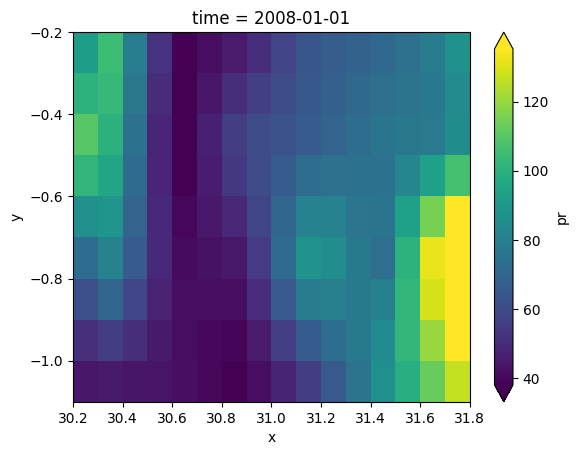

In [315]:
#Plot Spatial Distribution for One Time Step (Original Precipitation)
pr_10km.pr.isel(time = 84).plot(
    x = 'x', y = 'y', robust = True
)

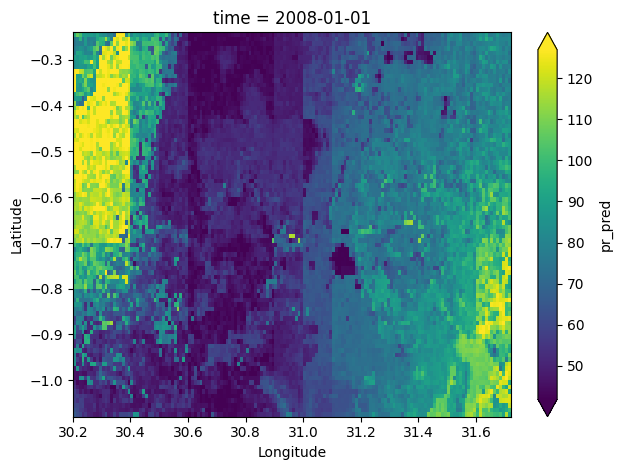

In [317]:
#Predicted Precipitation
pr_1km.isel(time = 84).plot(
    x = 'x', y = 'y', robust = True,
)

import matplotlib.pyplot as plt
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# **Point Extraction to csv**

In [278]:
#Extract and Export Monthly Predictions
import pandas as pd

#Rwizi Station Names and Cordinates
#1. Isingiro_814005; 30.816240, -0.815240
#2. Rakai_814017; 31.403100, -0.706100
#3. Rwonyo_814018; 30.96641, -0.63403

#Enter Station name and coordinates
station = 'Rwonyo'
lon, lat = 30.96641, -0.63403

# Extract monthly precipitation values from nearest grid cell
point = pr_1km.sel(
    x=lon,
    y=lat,
    method='nearest'
).compute()

monthly_values = (
    point
    .to_series()
    .rename('Precipitation_mm')
    .reset_index()
    [['time', 'Precipitation_mm']]
    .rename(columns={'time': 'Date'})
)

# Export to CSV
output_csv = f'{station}.csv'

monthly_values.to_csv(
    output_csv,
    index=False
)

print('Station:', station)
print('Selected grid cell:', float(point.x), float(point.y))
print('csv saved as:', output_csv)

Station: Rwonyo
Selected grid cell: 30.965 -0.635
csv saved as: Rwonyo.csv


# **Export Raw Precipitation (Before Downscaling)**

In [322]:
#Extract and Export raw 10km monthly precipitation
import pandas as pd

# Rwizi monitoring stations
# 1. Isingiro_814005: 30.816240, -0.815240
# 2. Rakai_814017:    31.403100, -0.706100
# 3. Rwonyo_814018:   30.966410, -0.634030

# Enter station name and coordinates
station = "Isingiro_raw_10km"
lon, lat = 30.816240, -0.815240

# Select the raw ERA5-Land precipitation variable
raw_precipitation = pr_10km["pr"]

# Extract the nearest 10-km grid cell
point = (
    raw_precipitation
    .sel(
        x=lon,
        y=lat,
        method="nearest"
    )
    .compute()
    .squeeze(drop=True)
)

# Convert the extracted time series to a table
monthly_values = (
    point
    .to_series()
    .rename("Precipitation_mm")
    .reset_index()
    [["time", "Precipitation_mm"]]
    .rename(columns={"time": "Date"})
)

# Export to CSV
output_csv = f"{station}.csv"

monthly_values.to_csv(
    output_csv,
    index=False
)

print("Station:", station)
print(
    "Requested coordinates:",
    lon,
    lat
)
print(
    "Selected 10-km grid cell:",
    float(point.x),
    float(point.y)
)
print("CSV saved as:", output_csv)

Station: Isingiro_raw_10km
Requested coordinates: 30.81624 -0.81524
Selected 10-km grid cell: 30.850000000000005 -0.8500000000000001
CSV saved as: Isingiro_raw_10km.csv
